Loaded 25 rows, 7 columns (encoding utf-8)
   voltage  tot_avg  tot_std  toa_avg  toa_std  efficiency_tot  efficiency_toa
0       54     2.97    0.171   15.440    0.967            1.00            1.00
1       53     2.99    0.100   15.650    0.978            1.00            1.00
2       52     2.93    0.293   16.300    1.299            1.00            1.00
3       51     2.93    0.256   16.570    1.037            1.00            1.00
4       50     2.78    0.462   17.580    2.152            1.00            1.00
5       49     2.56    0.641   17.710    1.320            1.00            1.00
6       48     2.17    0.779   18.410    1.491            1.00            1.00
7       47     1.79    0.715   19.270    1.399            1.00            1.00
8       46     1.42    0.589   20.323    1.883            0.99            0.99
9       45     1.33    0.533   20.747    1.913            0.99            0.99


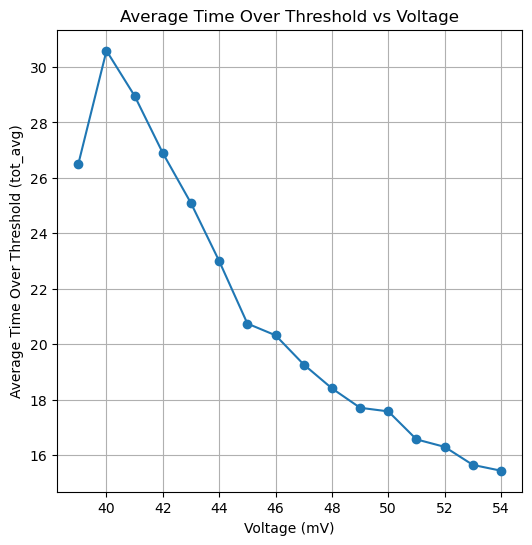

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from numpy.lib.scimath import sqrt
from scipy.special import erf


file_path = Path(r"C:\Users\andre\Documents\Microlab\Falaphel\TOT-AFE\BoardDAQ\falaphel3-daq\daq_software\export\data_falaphel_prin_251030_170839.tsv")

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

# Try reading with utf-8, fallback to latin-1 if necessary
for enc in ("utf-8", "latin-1"):
    try:
        df = pd.read_csv(file_path, sep="\t", encoding=enc, comment="#", low_memory=False)
        # drop the first data row and reset index
        df = df.iloc[1:].reset_index(drop=True)
        break
    except Exception:
        df = None
else:
    raise ValueError("Failed to read TSV with common encodings.")

print(f"Loaded {len(df)} rows, {len(df.columns)} columns (encoding {enc})")
print(df.head(10))

# Plot plt.plot con colonna voltage come x e tot_avg come y
plt.figure(figsize=(6, 6))
plt.plot(df["voltage"], df["toa_avg"], marker='o', linestyle='-')
plt.title("Average Time Over Threshold vs Voltage") 
plt.xlabel("Voltage (mV)")
plt.ylabel("Average Time Over Threshold (tot_avg)")
plt.grid(True)
plt.show()


##### Error function in the $(0,1)$ interval:
$\Phi(x, \mu, \sigma) = \frac{1}{2} ( 1 + Erf( \frac{x-\mu}{\sigma \sqrt(2)} ) )$ 

In [ ]:
def myERF(x, mu, sigma):
    return 0.5*(1 + erf((x-mu)/(sigma*sqrt(2))))

efficiency_tot -> Threshold: 41.4534 mV, Dispersion: 1.1793 mV
efficiency_toa -> Threshold: 41.0672 mV, Dispersion: 1.0535 mV


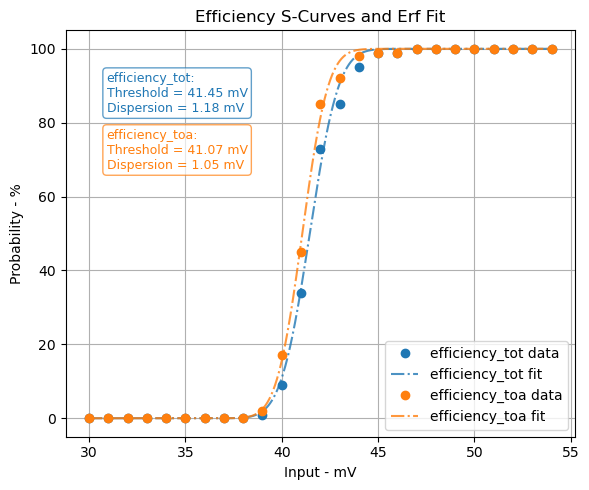

In [32]:
# Fit and plot efficiency S-curves for efficiency_tot and efficiency_toa
cols = ["efficiency_tot", "efficiency_toa"]
colors = {"efficiency_tot": "tab:blue", "efficiency_toa": "tab:orange"}

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

x_min, x_max = df["voltage"].min(), df["voltage"].max()
x_fit = np.linspace(x_min - 2, x_max + 2, 1000)

for i, col in enumerate(cols):
    if col not in df.columns:
        continue

    # prepare data (voltage = x, efficiency = y)
    valid = df[["voltage", col]].dropna()
    if len(valid) < 4:
        print(f"Not enough data to fit {col} (need >=4 points).")
        continue

    xdata = valid["voltage"].values
    ydata = valid[col].values  # in range 0..1

    # initial guess: mean near median voltage, dispersion ~ quarter of span
    guess = [np.median(xdata), max(1.0, (xdata.max() - xdata.min()) / 4.0)]

    try:
        popt, pcov = curve_fit(
            myERF,
            xdata,
            ydata,
            p0=guess,
            bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
        )
        fit_mu, fit_sigma = popt
    except Exception as e:
        print(f"Fit failed for {col}: {e}")
        continue

    # compute fit only inside the measured data range
    x_fit = np.linspace(xdata.min(), xdata.max(), 1000)
    fit_y = myERF(x_fit, fit_mu, fit_sigma)

    # plot data points as percent and fit as percent
    ax.plot(xdata, ydata * 100, "o", color=colors[col], label=f"{col} data")
    ax.plot(x_fit, fit_y * 100, "-.", color=colors[col], alpha=0.8, label=f"{col} fit")

    # annotate with threshold and dispersion (mV)
    ax.text(
        0.08,
        0.8 - i * 0.14,
        f"{col}:\nThreshold = {fit_mu:.2f} mV\nDispersion = {fit_sigma:.2f} mV",
        transform=ax.transAxes,
        color=colors[col],
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[col], alpha=0.7),
    )

    print(f"{col} -> Threshold: {fit_mu:.4f} mV, Dispersion: {fit_sigma:.4f} mV")

ax.set_xlabel("Input - mV")
ax.set_ylabel("Probability - %")
ax.set_title("Efficiency S-Curves and Erf Fit")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig("efficiency_s_curves.png", bbox_inches="tight")
plt.show()